In [5]:
import numpy as np
from PIL import Image
import cv2
import torch

import matplotlib.pyplot as plt
from transformers import pipeline
from PIL import Image
import requests

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from transformers import pipeline
from PIL import Image
import requests

# load pipe


# load image
# url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
# image = Image.open(requests.get(url, stream=True).raw)

# # inference
# depth = pipe(image)["depth"]


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use mps:0


In [7]:
pipe = pipeline(task="depth-estimation", model="LiheYoung/depth-anything-large-hf")

image = Image.open("./IMG_2295.JPG")
# image_org = np.array(image) / 255.0
# image_org = torch.from_numpy(image_org)
image_depth = depth = pipe(image)["depth"]
image_depth = torch.tensor(np.array(image_depth))
# image_depth = torch.load("./depth_tensor_full.pt")

Device set to use mps:0


In [8]:
image_depth = torch.tensor(np.array(image_depth))

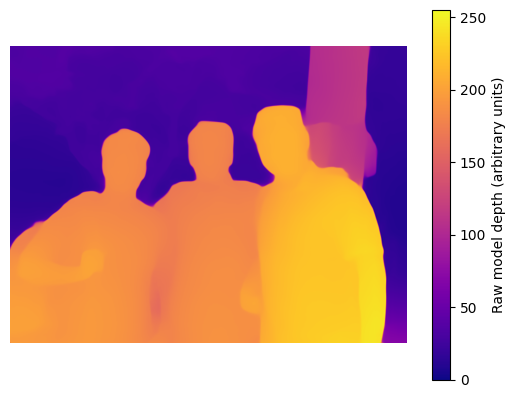

In [12]:
plt.imshow(image_depth, cmap='plasma')
plt.axis('off')
plt.colorbar(label='Raw model depth (arbitrary units)')
plt.show()

In [10]:
def refine_depth_with_bilateral(Z, I_rgb, diameter=9, sigma_color=0.1, sigma_space=10):
    """
    输入:
        Z: float32 depth (H×W), 单位米
        I_rgb: float32 RGB (H×W×3), [0,1]
    返回:
        Z_refined: 平滑后的深度
    """
    Z_norm = (Z - Z.min()) / (Z.max() - Z.min() + 1e-8)
    Z_ref = cv2.bilateralFilter(Z_norm, diameter, sigma_color*255, sigma_space)
    # 或者用引导滤波（guided filter），效果更好：
    # import cv2.ximgproc
    # Z_ref = cv2.ximgproc.guidedFilter(guide=(I_rgb*255).astype(np.uint8), src=Z_norm, radius=8, eps=1e-3)
    Z_ref = Z_ref * (Z.max() - Z.min()) + Z.min()
    return Z_ref

In [24]:
import numpy as np
import cv2
import torch
from PIL import Image

# ----- 1) 读取原图 -----
I_full = np.asarray(Image.open("./IMG_2295.JPG").convert("RGB"), dtype=np.float32) / 255.0
H0, W0 = I_full.shape[:2]
print(f"原图尺寸: {W0}x{H0}")

# ----- 2) 读取并处理深度图 -----
# Z_t = torch.load("./depth_tensor.pt", map_location="cpu")
Z_t= torch.tensor(np.array(pipe(image)["depth"]))
# print(Z_t)
if isinstance(Z_t, dict) and "image_depth" in Z_t:
    Z_t = Z_t["image_depth"]

Z = Z_t.detach().cpu().numpy().astype(np.float32)
print(f"原始深度范围: [{Z.min():.3f}, {Z.max():.3f}]")

# 归一化到 0-1
Z = (Z - Z.min()) / (Z.max() - Z.min() + 1e-8)

# 上采样到原图大小
Z = cv2.resize(Z, (W0, H0), interpolation=cv2.INTER_LINEAR)

# 使用双边滤波平滑深度（保持边缘）
Z = cv2.bilateralFilter(Z.astype(np.float32), d=9, sigmaColor=0.05, sigmaSpace=5)

# 深度到实际距离的映射（根据场景调整）
# 使用指数映射更符合真实深度分布
Z_min, Z_max = 0.5, 15.0  # 米
Z_real = Z_min * np.exp(Z * np.log(Z_max / Z_min))
print(f"映射后深度范围: [{Z_real.min():.2f}m, {Z_real.max():.2f}m]")

# 清理异常值
Z_real = np.clip(Z_real, Z_min, Z_max)
Z_real = cv2.medianBlur(Z_real, 3)

# ----- 3) 相机参数与CoC计算 -----
def compute_coc_radius(Z_m, focal_length_mm, f_number, focus_distance_m, 
                       sensor_width_mm, image_width_px, max_blur_px=40):
    """
    计算Circle of Confusion半径（像素）
    
    参数:
    - Z_m: 深度图（米）
    - focal_length_mm: 焦距（毫米）
    - f_number: 光圈值（f/#）
    - focus_distance_m: 对焦距离（米）
    - sensor_width_mm: 传感器宽度（毫米）
    - image_width_px: 图像宽度（像素）
    - max_blur_px: 最大模糊半径（像素）
    """
    # 像素大小（毫米/像素）
    pixel_size_mm = sensor_width_mm / image_width_px
    
    # 薄透镜公式: 1/f = 1/s + 1/s'
    f_m = focal_length_mm / 1000.0
    s = focus_distance_m
    
    # 光圈直径（毫米）
    aperture_diameter_mm = focal_length_mm / f_number
    
    # CoC直径（毫米）
    # CoC = (A * |s - z| * f) / (z * (s - f))
    eps = 1e-6
    numerator = aperture_diameter_mm * np.abs(s - Z_m) * f_m
    denominator = Z_m * (s - f_m) + eps
    coc_diameter_mm = numerator / (denominator + eps)
    
    # 转换为像素半径
    coc_radius_px = (coc_diameter_mm / pixel_size_mm) / 2.0
    
    # 限制范围
    coc_radius_px = np.clip(coc_radius_px, 0.0, max_blur_px)
    coc_radius_px = np.nan_to_num(coc_radius_px, nan=0.0, posinf=max_blur_px)
    
    return coc_radius_px.astype(np.float32)

# 相机参数（可调节）
FOCAL_LENGTH = 50.0      # 焦距 mm (50mm标准镜头)
F_NUMBER = 2.8          # 光圈 f/2.8 (大光圈)
SENSOR_WIDTH = 36.0      # 全画幅传感器宽度 mm
MAX_BLUR_PX = 40         # 最大模糊半径

# === 交互式选择对焦点 ===
def select_focus_interactive(image, depth_map):
    """
    鼠标点击图像选择对焦位置
    - 左键点击: 选择对焦点
    - 按 'q' 或 ESC: 确认选择
    """
    selected_point = {'x': W0//2, 'y': H0//2, 'depth': None}
    
    # 创建显示窗口
    display = image.copy()
    
    def mouse_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            selected_point['x'] = x
            selected_point['y'] = y
            selected_point['depth'] = depth_map[y, x]
            
            # 更新显示
            display_temp = image.copy()
            # 画十字标记
            cv2.drawMarker(display_temp, (x, y), (0, 1, 0), 
                          cv2.MARKER_CROSS, 30, 2)
            # 显示信息
            info_text = f"Focus: ({x}, {y}) Depth: {selected_point['depth']:.2f}m"
            cv2.putText(display_temp, info_text, (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 1, 0), 2)
            
            cv2.imshow('Select Focus Point', 
                      cv2.cvtColor((display_temp * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
            print(f"✓ 选择点: ({x}, {y}), 深度: {selected_point['depth']:.2f}m")
    
    # 初始显示
    cv2.namedWindow('Select Focus Point', cv2.WINDOW_NORMAL)
    cv2.setMouseCallback('Select Focus Point', mouse_callback)
    
    # 添加说明文字
    display_with_text = display.copy()
    cv2.putText(display_with_text, "Click on object to focus, press Q to confirm", 
               (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (1, 1, 0), 2)
    
    cv2.imshow('Select Focus Point', 
              cv2.cvtColor((display_with_text * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
    
    print("\n=== 交互式对焦点选择 ===")
    print("1. 在图像上点击你想对焦的物体")
    print("2. 按 'q' 或 ESC 确认选择\n")
    
    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or key == 27:  # q 或 ESC
            break
    
    cv2.destroyAllWindows()
    
    if selected_point['depth'] is None:
        selected_point['depth'] = depth_map[selected_point['y'], selected_point['x']]
    
    return selected_point['depth']

# 使用交互式选择（注释掉下面一行可以改回手动设置）
FOCUS_DISTANCE = select_focus_interactive(I_full, Z_real)
print(f"\n>>> 最终对焦距离: {FOCUS_DISTANCE:.2f}m\n")

# 或者手动设置（注释掉上面两行，启用下面）
# FOCUS_DISTANCE = 3.0

# 计算CoC
coc_radius = compute_coc_radius(
    Z_real, FOCAL_LENGTH, F_NUMBER, FOCUS_DISTANCE,
    SENSOR_WIDTH, W0, MAX_BLUR_PX
)

print(f"CoC半径范围: [{coc_radius.min():.2f}, {coc_radius.max():.2f}] 像素")

# ----- 4) 边缘感知调整（可选） -----
def edge_aware_coc(coc, image, depth, edge_threshold=0.05):
    """在深度边缘处减少模糊以避免光晕"""
    # 计算深度梯度
    depth_grad_x = cv2.Sobel(depth, cv2.CV_32F, 1, 0, ksize=3)
    depth_grad_y = cv2.Sobel(depth, cv2.CV_32F, 0, 1, ksize=3)
    depth_grad = np.sqrt(depth_grad_x**2 + depth_grad_y**2)
    
    # 归一化梯度
    depth_grad_norm = depth_grad / (np.percentile(depth_grad, 99) + 1e-6)
    
    # 在边缘处降低CoC
    edge_mask = depth_grad_norm > edge_threshold
    coc_adjusted = coc.copy()
    coc_adjusted[edge_mask] *= 0.5  # 边缘处减半
    
    return coc_adjusted

# 应用边缘感知（可以注释掉这行来对比效果）
# coc_radius = edge_aware_coc(coc_radius, I_full, Z_real, edge_threshold=0.03)

# ----- 5) 分层模糊（高效实现） -----
def layered_blur_efficient(image, coc_map, num_layers=10, max_radius=40):
    """
    使用分层模糊实现可变模糊效果
    
    参数:
    - image: 输入图像 [H,W,3]
    - coc_map: CoC半径图 [H,W]
    - num_layers: 模糊层数
    - max_radius: 最大模糊半径
    """
    H, W = image.shape[:2]
    
    # 创建模糊层
    blur_radii = np.linspace(0, max_radius, num_layers)
    blur_layers = []
    
    print("生成模糊层...")
    for i, radius in enumerate(blur_radii):
        if radius < 0.5:
            blur_layers.append(image.copy())
        else:
            # 使用高斯模糊（比圆盘卷积快）
            sigma = radius / 2.0  # 经验转换
            blurred = cv2.GaussianBlur(image, (0, 0), sigma, borderType=cv2.BORDER_REFLECT)
            blur_layers.append(blurred)
        print(f"  层 {i+1}/{num_layers}: 半径={radius:.1f}px", end='\r')
    print()
    
    # 为每个像素选择合适的模糊层（矢量化）
    # 将CoC映射到层索引
    layer_indices = np.clip(
        (coc_map / max_radius) * (num_layers - 1),
        0, num_layers - 1
    )
    
    idx_low = np.floor(layer_indices).astype(np.int32)
    idx_high = np.ceil(layer_indices).astype(np.int32)
    alpha = (layer_indices - idx_low).astype(np.float32)
    
    # 插值混合
    print("混合模糊层...")
    result = np.zeros_like(image)
    for i in range(num_layers):
        mask_low = (idx_low == i).astype(np.float32)
        mask_high = (idx_high == i).astype(np.float32)
        
        weight_low = mask_low * (1 - alpha)
        weight_high = mask_high * alpha
        weight_total = weight_low + weight_high
        
        if weight_total.max() > 0:
            result += blur_layers[i] * weight_total[:, :, np.newaxis]
    
    return np.clip(result, 0.0, 1.0)

# 执行分层模糊
print("\n开始景深模拟...")
result = layered_blur_efficient(I_full, coc_radius, num_layers=15, max_radius=MAX_BLUR_PX)

# ----- 6) 保存结果 -----
# 保存模糊结果
output_path = "refocus_optimized.png"
cv2.imwrite(output_path, cv2.cvtColor((result * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
print(f"✅ 已保存: {output_path}")

# 保存深度可视化
depth_vis = ((Z_real - Z_real.min()) / (Z_real.max() - Z_real.min()) * 255).astype(np.uint8)
depth_vis = cv2.applyColorMap(depth_vis, cv2.COLORMAP_TURBO)
cv2.imwrite("depth_visualization.png", depth_vis)
print("✅ 已保存深度可视化: depth_visualization.png")

# 保存CoC可视化
coc_vis = (coc_radius / MAX_BLUR_PX * 255).astype(np.uint8)
coc_vis = cv2.applyColorMap(coc_vis, cv2.COLORMAP_JET)
cv2.imwrite("coc_visualization.png", coc_vis)
print("✅ 已保存CoC可视化: coc_visualization.png")

# ----- 7) 参数建议 -----
print("\n=== 参数调节建议 ===")
print(f"当前设置:")
print(f"  焦距: {FOCAL_LENGTH}mm")
print(f"  光圈: f/{F_NUMBER}")
print(f"  对焦距离: {FOCUS_DISTANCE}m")
print(f"\n效果调节:")
print(f"  - 增大光圈(减小F_NUMBER): 更强的景深效果")
print(f"  - 增大焦距: 更强的景深效果")
print(f"  - 调整FOCUS_DISTANCE到你想清晰的深度")
print(f"  - 修改Z_min/Z_max匹配实际场景深度范围")

原图尺寸: 1707x1280
原始深度范围: [0.000, 255.000]
映射后深度范围: [0.54m, 13.71m]

=== 交互式对焦点选择 ===
1. 在图像上点击你想对焦的物体
2. 按 'q' 或 ESC 确认选择

✓ 选择点: (867, 502), 深度: 5.59m
✓ 选择点: (504, 488), 深度: 5.85m
✓ 选择点: (845, 490), 深度: 5.59m
✓ 选择点: (645, 238), 深度: 0.72m
✓ 选择点: (561, 217), 深度: 0.72m
✓ 选择点: (386, 300), 深度: 0.70m
✓ 选择点: (251, 517), 深度: 0.60m
✓ 选择点: (263, 648), 深度: 0.61m
✓ 选择点: (484, 883), 深度: 6.06m
✓ 选择点: (398, 966), 深度: 6.65m
✓ 选择点: (359, 956), 深度: 7.37m
✓ 选择点: (845, 478), 深度: 5.59m
✓ 选择点: (860, 486), 深度: 5.59m

>>> 最终对焦距离: 5.59m

CoC半径范围: [0.00, 34.63] 像素

开始景深模拟...
生成模糊层...
  层 15/15: 半径=40.0px
混合模糊层...
✅ 已保存: refocus_optimized.png
✅ 已保存深度可视化: depth_visualization.png
✅ 已保存CoC可视化: coc_visualization.png

=== 参数调节建议 ===
当前设置:
  焦距: 50.0mm
  光圈: f/2.8
  对焦距离: 5.590319633483887m

效果调节:
  - 增大光圈(减小F_NUMBER): 更强的景深效果
  - 增大焦距: 更强的景深效果
  - 调整FOCUS_DISTANCE到你想清晰的深度
  - 修改Z_min/Z_max匹配实际场景深度范围


: 

In [23]:
import numpy as np
import cv2
import torch
from PIL import Image

# ----- 1) 读取原图 -----
I_full = np.asarray(Image.open("./IMG_2295.JPG").convert("RGB"), dtype=np.float32) / 255.0
H0, W0 = I_full.shape[:2]
print(f"原图尺寸: {W0}x{H0}")

# ----- 2) 读取并处理深度图 -----
Z_t = torch.load("./depth_tensor.pt", map_location="cpu")
if isinstance(Z_t, dict) and "image_depth" in Z_t:
    Z_t = Z_t["image_depth"]

Z = Z_t.detach().cpu().numpy().astype(np.float32)
print(f"原始深度范围: [{Z.min():.3f}, {Z.max():.3f}]")

# 归一化到 0-1
Z = (Z - Z.min()) / (Z.max() - Z.min() + 1e-8)

# 上采样到原图大小
Z = cv2.resize(Z, (W0, H0), interpolation=cv2.INTER_LINEAR)

# 使用双边滤波平滑深度（保持边缘）
Z = cv2.bilateralFilter(Z.astype(np.float32), d=9, sigmaColor=0.05, sigmaSpace=5)

# 深度到实际距离的映射
Z_min, Z_max = 0.5, 15.0
Z_real = Z_min * np.exp(Z * np.log(Z_max / Z_min))
print(f"映射后深度范围: [{Z_real.min():.2f}m, {Z_real.max():.2f}m]")

Z_real = np.clip(Z_real, Z_min, Z_max)
Z_real = cv2.medianBlur(Z_real, 3)

# ----- 3) CoC计算 -----
def compute_coc_radius(Z_m, focal_length_mm, f_number, focus_distance_m, 
                       sensor_width_mm, image_width_px, max_blur_px=40):
    pixel_size_mm = sensor_width_mm / image_width_px
    f_m = focal_length_mm / 1000.0
    s = focus_distance_m
    aperture_diameter_mm = focal_length_mm / f_number
    
    eps = 1e-6
    numerator = aperture_diameter_mm * np.abs(s - Z_m) * f_m
    denominator = Z_m * (s - f_m) + eps
    coc_diameter_mm = numerator / (denominator + eps)
    coc_radius_px = (coc_diameter_mm / pixel_size_mm) / 2.0
    coc_radius_px = np.clip(coc_radius_px, 0.0, max_blur_px)
    coc_radius_px = np.nan_to_num(coc_radius_px, nan=0.0, posinf=max_blur_px)
    
    return coc_radius_px.astype(np.float32)

# ----- 4) 相机参数与交互式选择 -----
FOCAL_LENGTH = 50.0
F_NUMBER = 8.0
SENSOR_WIDTH = 36.0
MAX_BLUR_PX = 40

def select_focus_interactive(image, depth_map):
    selected_point = {'x': W0//2, 'y': H0//2, 'depth': None}
    display = image.copy()
    
    def mouse_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            selected_point['x'] = x
            selected_point['y'] = y
            selected_point['depth'] = depth_map[y, x]
            
            display_temp = image.copy()
            cv2.drawMarker(display_temp, (x, y), (0, 1, 0), 
                          cv2.MARKER_CROSS, 30, 2)
            info_text = f"Focus: ({x}, {y}) Depth: {selected_point['depth']:.2f}m"
            cv2.putText(display_temp, info_text, (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 1, 0), 2)
            
            cv2.imshow('Select Focus Point', 
                      cv2.cvtColor((display_temp * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
            print(f"✓ 选择点: ({x}, {y}), 深度: {selected_point['depth']:.2f}m")
    
    cv2.namedWindow('Select Focus Point', cv2.WINDOW_NORMAL)
    cv2.setMouseCallback('Select Focus Point', mouse_callback)
    
    display_with_text = display.copy()
    cv2.putText(display_with_text, "Click on object to focus, press Q to confirm", 
               (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (1, 1, 0), 2)
    
    cv2.imshow('Select Focus Point', 
              cv2.cvtColor((display_with_text * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
    
    print("\n=== 交互式对焦点选择 ===")
    print("1. 在图像上点击你想对焦的物体")
    print("2. 按 'q' 或 ESC 确认选择\n")
    
    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or key == 27:
            break
    
    cv2.destroyAllWindows()
    
    if selected_point['depth'] is None:
        selected_point['depth'] = depth_map[selected_point['y'], selected_point['x']]
    
    return selected_point['depth']

FOCUS_DISTANCE = select_focus_interactive(I_full, Z_real)
print(f"\n>>> 最终对焦距离: {FOCUS_DISTANCE:.2f}m\n")

# 计算CoC
coc_radius = compute_coc_radius(
    Z_real, FOCAL_LENGTH, F_NUMBER, FOCUS_DISTANCE,
    SENSOR_WIDTH, W0, MAX_BLUR_PX
)

print(f"CoC半径范围: [{coc_radius.min():.2f}, {coc_radius.max():.2f}] 像素")

# ----- 5) 改进的分层散焦渲染（前后景分离） -----
def layered_dof_with_matting(image, depth, coc_map, focus_depth, num_layers=12, max_radius=40):
    """
    使用前后景分离和软抠图的景深渲染
    
    关键改进：
    1. 分离前景和背景
    2. 对前景边缘进行软抠图
    3. 先模糊背景，再合成清晰前景
    """
    H, W = image.shape[:2]
    
    # === 1) 检测前景/背景边界 ===
    # 前景定义：深度小于对焦距离（离相机更近）
    foreground_threshold = focus_depth * 0.9  # 稍微扩大前景范围
    is_foreground = (depth <= foreground_threshold).astype(np.float32)
    
    # 生成软边缘遮罩（使用深度梯度）
    depth_grad_x = cv2.Sobel(depth, cv2.CV_32F, 1, 0, ksize=5)
    depth_grad_y = cv2.Sobel(depth, cv2.CV_32F, 0, 1, ksize=5)
    depth_grad = np.sqrt(depth_grad_x**2 + depth_grad_y**2)
    
    # 边缘区域
    edge_threshold = np.percentile(depth_grad, 90)
    is_edge = (depth_grad > edge_threshold * 0.5).astype(np.float32)
    
    # 软化前景遮罩（避免硬边）
    fg_mask = is_foreground.copy()
    fg_mask = cv2.GaussianBlur(fg_mask, (15, 15), 3.0)
    fg_mask = np.clip(fg_mask, 0.0, 1.0)
    
    # 在边缘区域进一步软化
    edge_dilated = cv2.dilate(is_edge, np.ones((11, 11), np.uint8), iterations=1)
    fg_mask = np.where(edge_dilated > 0.5, 
                       cv2.GaussianBlur(fg_mask, (25, 25), 5.0),
                       fg_mask)
    
    # === 2) 创建分层模糊 ===
    blur_radii = np.linspace(0, max_radius, num_layers)
    blur_layers = []
    
    print("生成模糊层...")
    for i, radius in enumerate(blur_radii):
        if radius < 0.5:
            blur_layers.append(image.copy())
        else:
            sigma = radius / 2.0
            blurred = cv2.GaussianBlur(image, (0, 0), sigma, borderType=cv2.BORDER_REFLECT)
            blur_layers.append(blurred)
        print(f"  层 {i+1}/{num_layers}: 半径={radius:.1f}px", end='\r')
    print()
    
    # === 3) 背景渲染（完整模糊） ===
    print("渲染背景...")
    bg_coc = coc_map * (1.0 - fg_mask)  # 背景CoC
    
    layer_indices_bg = np.clip(
        (bg_coc / max_radius) * (num_layers - 1),
        0, num_layers - 1
    )
    
    idx_low = np.floor(layer_indices_bg).astype(np.int32)
    idx_high = np.ceil(layer_indices_bg).astype(np.int32)
    alpha = (layer_indices_bg - idx_low).astype(np.float32)
    
    background = np.zeros_like(image)
    for i in range(num_layers):
        mask_low = (idx_low == i).astype(np.float32)
        mask_high = (idx_high == i).astype(np.float32)
        
        weight_low = mask_low * (1 - alpha)
        weight_high = mask_high * alpha
        weight_total = weight_low + weight_high
        
        if weight_total.max() > 0:
            background += blur_layers[i] * weight_total[:, :, np.newaxis]
    
    # === 4) 前景渲染（保留细节） ===
    print("渲染前景...")
    fg_coc = coc_map * fg_mask  # 前景CoC
    
    layer_indices_fg = np.clip(
        (fg_coc / max_radius) * (num_layers - 1),
        0, num_layers - 1
    )
    
    idx_low_fg = np.floor(layer_indices_fg).astype(np.int32)
    idx_high_fg = np.ceil(layer_indices_fg).astype(np.int32)
    alpha_fg = (layer_indices_fg - idx_low_fg).astype(np.float32)
    
    foreground = np.zeros_like(image)
    for i in range(num_layers):
        mask_low = (idx_low_fg == i).astype(np.float32)
        mask_high = (idx_high_fg == i).astype(np.float32)
        
        weight_low = mask_low * (1 - alpha_fg)
        weight_high = mask_high * alpha_fg
        weight_total = weight_low + weight_high
        
        if weight_total.max() > 0:
            foreground += blur_layers[i] * weight_total[:, :, np.newaxis]
    
    # === 5) 合成：前景覆盖背景 ===
    print("合成最终图像...")
    fg_mask_3ch = fg_mask[:, :, np.newaxis]
    result = foreground * fg_mask_3ch + background * (1.0 - fg_mask_3ch)
    
    # 保存调试信息
    cv2.imwrite("debug_fg_mask.png", (fg_mask * 255).astype(np.uint8))
    cv2.imwrite("debug_edges.png", (is_edge * 255).astype(np.uint8))
    print("  调试图已保存: debug_fg_mask.png, debug_edges.png")
    
    return np.clip(result, 0.0, 1.0)

# 执行渲染
print("\n开始景深模拟...")
result = layered_dof_with_matting(I_full, Z_real, coc_radius, FOCUS_DISTANCE, 
                                   num_layers=15, max_radius=MAX_BLUR_PX)

# ----- 6) 保存结果 -----
output_path = "refocus_edge_fixed.png"
cv2.imwrite(output_path, cv2.cvtColor((result * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
print(f"✅ 已保存: {output_path}")

# 深度可视化
depth_vis = ((Z_real - Z_real.min()) / (Z_real.max() - Z_real.min()) * 255).astype(np.uint8)
depth_vis = cv2.applyColorMap(depth_vis, cv2.COLORMAP_TURBO)
cv2.imwrite("depth_visualization.png", depth_vis)

# CoC可视化
coc_vis = (coc_radius / MAX_BLUR_PX * 255).astype(np.uint8)
coc_vis = cv2.applyColorMap(coc_vis, cv2.COLORMAP_JET)
cv2.imwrite("coc_visualization.png", coc_vis)

print("\n=== 完成 ===")
print(f"主要改进: 前后景分离渲染，边缘软抠图")
print(f"如果边缘仍有问题，可调整:")
print(f"  - foreground_threshold = focus_depth * 0.9  (调大扩大前景)")
print(f"  - GaussianBlur核大小 (15,15) 和 (25,25)  (调大更柔和)")

原图尺寸: 1707x1280
原始深度范围: [0.000, 522.301]
映射后深度范围: [0.50m, 14.68m]

=== 交互式对焦点选择 ===
1. 在图像上点击你想对焦的物体
2. 按 'q' 或 ESC 确认选择

✓ 选择点: (861, 489), 深度: 1.03m

>>> 最终对焦距离: 1.03m

CoC半径范围: [0.00, 8.02] 像素

开始景深模拟...
生成模糊层...
  层 15/15: 半径=40.0px
渲染背景...
渲染前景...
合成最终图像...
  调试图已保存: debug_fg_mask.png, debug_edges.png
✅ 已保存: refocus_edge_fixed.png

=== 完成 ===
主要改进: 前后景分离渲染，边缘软抠图
如果边缘仍有问题，可调整:
  - foreground_threshold = focus_depth * 0.9  (调大扩大前景)
  - GaussianBlur核大小 (15,15) 和 (25,25)  (调大更柔和)
